Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 6: Persiapan Data


## Langkah 1: Load & EDA Singkat

Muat dataset, periksa missing values, tipe data, dan distribusi target `survived`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')

cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df = df[cols].copy()

print('Shape dataset:', df.shape)
print('\nTipe data tiap kolom:')
print(df.dtypes)
print('\nMissing values per kolom:')
print(df.isnull().sum())
print('\nDistribusi target (survived):')
print(df['survived'].value_counts(normalize=True).round(3))
print('→ survived=0 (~61.6%) dan survived=1 (~38.4%) — kelas tidak seimbang!')

print('\nPreview 5 baris pertama:')
df.head()


Shape dataset: (891, 8)

Tipe data tiap kolom:
pclass        int64
sex             str
age         float64
sibsp         int64
parch         int64
fare        float64
embarked        str
survived      int64
dtype: object

Missing values per kolom:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi target (survived):
survived
0    0.616
1    0.384
Name: proportion, dtype: float64
→ survived=0 (~61.6%) dan survived=1 (~38.4%) — kelas tidak seimbang!

Preview 5 baris pertama:


   pclass     sex   age  sibsp  parch     fare embarked  survived
0       3    male  22.0      1      0   7.2500        S         0
1       1  female  38.0      1      0  71.2833        C         1
2       3  female  26.0      0      0   7.9250        S         1
3       1  female  35.0      1      0  53.1000        S         1
4       3    male  35.0      0      0   8.0500        S         0

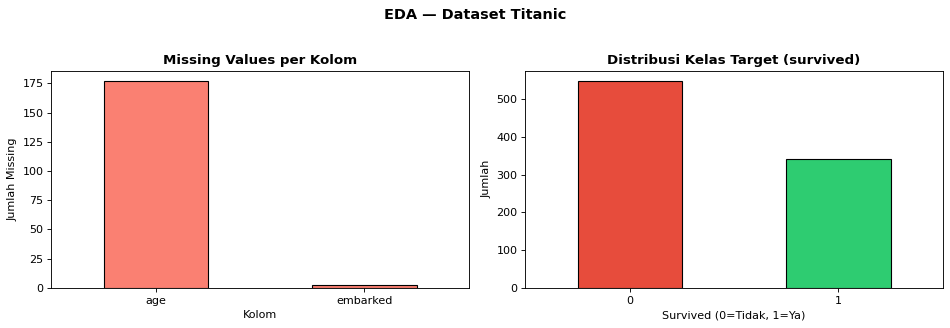

In [2]:
# Visualisasi distribusi missing values dan target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

missing = df.isnull().sum()
missing[missing > 0].plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Missing Values per Kolom', fontweight='bold')
axes[0].set_ylabel('Jumlah Missing')
axes[0].set_xlabel('Kolom')
axes[0].tick_params(axis='x', rotation=0)

df['survived'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#E74C3C', '#2ECC71'], edgecolor='black'
)
axes[1].set_title('Distribusi Kelas Target (survived)', fontweight='bold')
axes[1].set_ylabel('Jumlah')
axes[1].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('EDA — Dataset Titanic', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Langkah 2: Handling Missing Values

Isi nilai yang hilang sebelum encoding. Gunakan median untuk `age` dan modus untuk `embarked`.


In [3]:
# Age: isi dengan median (robust terhadap outlier)
df['age'] = df['age'].fillna(df['age'].median())

# Embarked: isi dengan modus (nilai paling sering)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

print('Missing setelah handling:')
print(df.isnull().sum())


Missing setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


## Langkah 3: Encoding Kategorikal

Terapkan One-Hot Encoding pada kolom `sex` dan `embarked` dengan `drop_first=True`.


In [4]:
# One-Hot Encoding untuk 'sex' dan 'embarked'
df = pd.get_dummies(df,
    columns=['sex', 'embarked'],
    drop_first=True,
    dtype=int)

print('Kolom setelah encoding:')
print(df.columns.tolist())
df.head()


Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


   pclass   age  sibsp  parch     fare  survived  sex_male  embarked_Q  embarked_S
0       3  22.0      1      0   7.2500         0         1           0           1
1       1  38.0      1      0  71.2833         1         0           0           0
2       3  26.0      0      0   7.9250         1         0           0           1
3       1  35.0      1      0  53.1000         1         0           0           1
4       3  35.0      0      0   8.0500         0         1           0           1

## Langkah 4: Train-Test Split (Stratified)

Bagi data 80% train / 20% test dengan `stratify=y` agar proporsi kelas terjaga.


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape[0]} baris')
print(f'Test : {X_test.shape[0]} baris')
print('\nProporsi survived di Train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nProporsi survived di Test:')
print(y_test.value_counts(normalize=True).round(3))


Train: 712 baris
Test : 179 baris

Proporsi survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


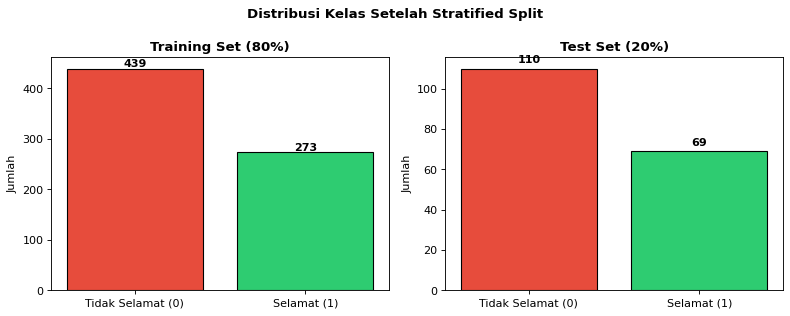

In [6]:
# Visualisasi proporsi kelas setelah split
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, label in zip(axes, [y_train, y_test], ['Training Set (80%)', 'Test Set (20%)']):
    counts = data.value_counts()
    bars = ax.bar(['Tidak Selamat (0)', 'Selamat (1)'],
                  [counts.get(0, 0), counts.get(1, 0)],
                  color=['#E74C3C', '#2ECC71'], edgecolor='black')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Jumlah')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 3,
                f'{int(bar.get_height())}', ha='center', fontweight='bold')

plt.suptitle('Distribusi Kelas Setelah Stratified Split', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Langkah 5: Feature Scaling (StandardScaler)

Terapkan StandardScaler hanya pada kolom numerik. Fit dari data train, transform ke test.


In [7]:
from sklearn.preprocessing import StandardScaler

num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare']
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print('Mean scaler (dari train):', scaler.mean_.round(2))
print('Std scaler (dari train):', scaler.scale_.round(2))
print()
print('Contoh X_train setelah scaling:')
print(X_train.head(3).round(3))
print('\nData siap dilatih model Machine Learning!')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}, y_test : {y_test.shape}')


Mean scaler (dari train): [ 2.31 29.46  0.49  0.39 31.82]
Std scaler (dari train): [ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train setelah scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1

Data siap dilatih model Machine Learning!
X_train: (712, 8), y_train: (712,)
X_test : (179, 8), y_test : (179,)


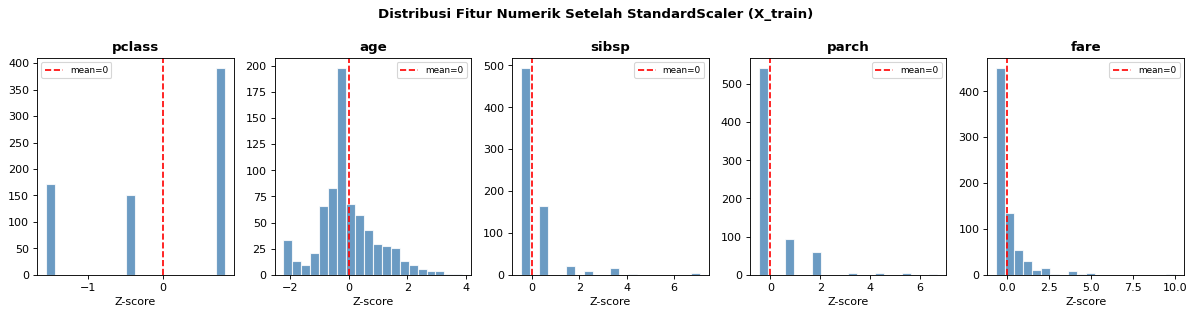

In [8]:
# Visualisasi distribusi fitur numerik setelah scaling (dari training set)
fig, axes = plt.subplots(1, len(num_cols), figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    ax.hist(X_train[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='mean=0')
    ax.set_title(f'{col}', fontweight='bold')
    ax.set_xlabel('Z-score')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik Setelah StandardScaler (X_train)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Kesimpulan

### Apa yang Dipelajari
- Pipeline preprocessing ML: handling missing values → One-Hot Encoding → train-test split → scaling
- Imputasi median (`age`) dan modus (`embarked`) pada dataset Titanic
- Stratified split agar proporsi kelas `survived` tetap seimbang
- StandardScaler: fit pada train, transform pada test

### Temuan Utama
- Dataset Titanic tidak seimbang (~62% tidak selamat) — stratify wajib
- Urutan preprocessing penting: scaling sebelum split menyebabkan data leakage
- Setelah pipeline, data siap untuk pelatihan model klasifikasi

### Keterbatasan
- Imputasi sederhana belum mempertimbangkan pola multivariat
- Belum ada feature selection atau penanganan outlier pada `fare`
